# Train XGBoost Model

## Motivation
**XGBoost** was chosen for this task for a few main reasons:

1. **High Performance** — It naturally captures complex, non-linear patterns by building a sequence of trees where each corrects the errors of the previous one.
2. **Imbalance Handling** — Our dataset is 80/20. XGBoost uses the `scale_pos_weight` parameter to heavily penalize missed alarms (False Negatives).
3. **Robustness** — It doesn't require feature scaling (`StandardScaler`) and automatically handles missing data.
4. **Interpretability** — Native `feature_importances_` allows us to easily find the top 20 features.

In [1]:
import os
os.chdir('..')

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from time import time
from pathlib import Path
import warnings

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, BaseCrossValidator
from sklearn.metrics import f1_score, roc_auc_score, matthews_corrcoef, precision_score, recall_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import matthews_corrcoef
from sklearn.inspection import permutation_importance
from app.db.database import Database

warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("data/merged/merged_preprocessed.csv")

df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert("Europe/Kyiv")
df = df.sort_values(by=["region_id", "time"]).reset_index(drop=True)

drop_cols = ['date', 'region_city', 'year', 'month', 'day']

target = 'alarm'
X = df.drop(columns=drop_cols, errors='ignore')
y = X.pop(target)

X.shape, y.shape

((823488, 113), (823488,))

# Functions

In [6]:
cat_cols = list(X.select_dtypes(include=["category", "object"], exclude=["datetime"]).columns)
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    # ('label_encode', LabelEncoder(), cat_cols),
    # ('scale', StandardScaler(), num_cols),
    ("drop_cols", "drop", ["time"]),
], remainder='passthrough')


def evaluate_model(pipeline, X=X, y=y, n_splits: int = 10, gap: int = 24, max_train_size=None, weights_func=None):
    
    f1_train_scores = []
    f1_test_scores  = []
    roc_auc_test_scores = []
    pr_auc_test_scores = []
    mcc_test_scores = []
    precision_test_scores = []
    recall_test_scores = []
    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    training_start = time()
    
    unique_hours = X["time"].sort_values().unique()
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap, max_train_size=max_train_size)
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
        train_hours = unique_hours[train_idx]
        test_hours  = unique_hours[test_idx]
        train_mask = X["time"].isin(train_hours) 
        test_mask  = X["time"].isin(test_hours)
               
        X_train = X[train_mask]
        y_train = y[train_mask]
        X_test  = X[test_mask]
        y_test  = y[test_mask]
        
        sample_weights = weights_func(X_train, y_train) if weights_func else None
        
        pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)
        y_pred_train = pipeline.predict(X_train)
        y_pred_test  = pipeline.predict(X_test)
        y_proba_test = pipeline.predict_proba(X_test)[:, 1]

        train_score = f1_score(y_train, y_pred_train)
        f1_train_scores.append(train_score)
        test_score = f1_score(y_test, y_pred_test)
        f1_test_scores.append(test_score)
        
        roc_auc = roc_auc_score(y_test, y_proba_test)
        roc_auc_test_scores.append(roc_auc)
        
        pr_auc = average_precision_score(y_test, y_proba_test)
        pr_auc_test_scores.append(pr_auc)

        mcc = matthews_corrcoef(y_test, y_pred_test)
        mcc_test_scores.append(mcc)
        precision = precision_score(y_test, y_pred_test)
        precision_test_scores.append(precision)
        recall = recall_score(y_test, y_pred_test)
        recall_test_scores.append(recall)
        
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred_test)
        all_y_proba.extend(y_proba_test)

    print("------------- Evaluation Results -------------")
    print(f"Train F1       : {np.mean(f1_train_scores):.3f} ± {np.std(f1_train_scores):.3f}")
    print(f"Test  F1       : {np.mean(f1_test_scores):.3f} ± {np.std(f1_test_scores):.3f}")
    print(f"Test  Precision: {np.mean(precision_test_scores):.3f} ± {np.std(precision_test_scores):.3f}")
    print(f"Test  Recall   : {np.mean(recall_test_scores):.3f} ± {np.std(recall_test_scores):.3f}")
    print(f"Test  ROC_AUC  : {np.mean(roc_auc_test_scores):.3f} ± {np.std(roc_auc_test_scores):.3f}")
    print(f"Test  PR_AUC   : {np.mean(pr_auc_test_scores):.3f} ± {np.std(pr_auc_test_scores):.3f}")
    print(f"Test  MCC      : {np.mean(mcc_test_scores):.3f} ± {np.std(mcc_test_scores):.3f}")
    print(f"")
    print(f"Completed in: {time() - training_start:.2f}s.")
    
    scores = pd.DataFrame({
        "train_f1":       f1_train_scores,
        "test_f1":        f1_test_scores, 
        "test_precision": precision_test_scores,
        "test_recall":    recall_test_scores,
        "test_roc_auc":   roc_auc_test_scores,
        "test_pr_auc":    pr_auc_test_scores,
        "test_mcc":       mcc_test_scores,
    })
    
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    return scores, overall_cm

In [17]:
def plot_results(scores, cm, title=None):
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    sns.lineplot(scores[['train_f1', 'test_f1']])
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    ConfusionMatrixDisplay(cm).plot(ax=plt.subplot(1, 2, 2))
    if title:
        plt.suptitle(title)
    plt.show()

In [8]:
def calculate_transition_weights(X, y):
    is_change = X['alarm_status_1h_ago'].values != y.values
    n_same = (~is_change).sum()
    n_change = is_change.sum()
    weight_change = n_same / n_change
    sample_weights = np.where(is_change, weight_change, 1.0)
    return sample_weights

def combined_weights(X, y):
    transition_weights = calculate_transition_weights(X, y)
    
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    
    class_w = np.where(y == 1, n_neg / n_pos, 1.0)
    sample_weights = transition_weights * class_w
    return sample_weights

In [9]:
from app.db.database import Database


with Database("app/db/database.db") as db:
    new_data = db.get_merged(start_date='2026-04-08')

from sklearn.metrics import precision_recall_curve, auc

def check_on_new_data(pipeline, new_data=new_data):
    X_test = new_data.copy()
    y_test = X_test.pop(target)
    
    y_preds = pipeline.predict(X_test)
    y_pred_probs = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1_score_ = f1_score(y_test, y_preds)
    roc_auc = roc_auc_score(y_test, y_pred_probs)
    mcc_score_ = matthews_corrcoef(y_test, y_preds)
    precision_ = precision_score(y_test, y_preds)
    recall_ = recall_score(y_test, y_preds)
    pr_auc = average_precision_score(y_test, y_pred_probs)
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_preds)
    
    # Predictions dataframe
    res = X_test[['region_id', 'time']].copy()
    res['alarm'] = y_test
    res['prediction'] = y_preds
    res['pred_prob_1'] = y_pred_probs
    
    # Metrics dataframe
    metrics_df = pd.DataFrame({
        'f1_score': [f1_score_],
        'roc_auc': [roc_auc],
        'pr_auc': [pr_auc],
        'mcc': [mcc_score_],
        'precision': [precision_],
        'recall': [recall_]
    })
    
    return res, metrics_df, cm

Commiting


In [10]:
def pipeline_factory(params, preprocessor=preprocessor, random_state=42):
    params = {**params, **{k: v for k, v in {'random_state': random_state}.items() if k not in params}}
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(**params)),
    ])

In [11]:
def get_feature_importance(pipeline, base=new_data):
    X_new_hourly = base.drop(columns=target)
    y_new_hourly = base[target]
    mask = ~y_new_hourly.isna()
    X_new_hourly = X_new_hourly[mask]
    y_new_hourly = y_new_hourly[mask]
    
    perm = permutation_importance(
        estimator=pipeline,
        X=X_new_hourly,
        y=y_new_hourly,
        scoring="f1",
        n_repeats=5,
        random_state=42,
        # n_jobs=-1,
    )
    
    importance_df = pd.DataFrame({
        "feature": X_new_hourly.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    
    # Convert to percentages relative to the total absolute importance
    total = importance_df["importance_mean"].abs().sum()
    importance_df["importance_pct"] = (importance_df["importance_mean"] / total * 100).round(2)
    importance_df["importance_std_pct"] = (importance_df["importance_std"] / total * 100).round(2)
    return importance_df[["feature", "importance_pct", "importance_std_pct"]]

In [73]:
def plot_feature_importances(df, title):
    plt.figure(figsize=(10, 8))
    plt.barh(df["feature"][::-1], df["importance_pct"][::-1])
    plt.xlabel("feature importance (percents)")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [13]:
mask = X.time >= '2025'
X_from_2025 = X.loc[mask]
y_from_2025 = y.loc[mask]

X_from_2025.shape, y_from_2025.shape

((244754, 113), (244754,))

# Base Model

XGBoost with `scale_pos_weight` should inherently shift predictions to minimize False Negatives, prioritizing Recall over Precision.

In [16]:
ratio = (df['alarm'] == 0).sum() / (df['alarm'] == 1).sum()
scale_weight = round(ratio, 2)
print(f"scale_pos_weight: {scale_weight}")

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        enable_categorical=True,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

scores, cm = evaluate_model(pipeline)

scale_pos_weight: 3.88
------------- Evaluation Results -------------
Train F1       : 0.674 ± 0.020
Test  F1       : 0.694 ± 0.065
Test  Precision: 0.639 ± 0.039
Test  Recall   : 0.767 ± 0.110
Test  ROC_AUC  : 0.909 ± 0.032
Test  PR_AUC   : 0.810 ± 0.076
Test  MCC      : 0.613 ± 0.055

Completed in: 37.95s.


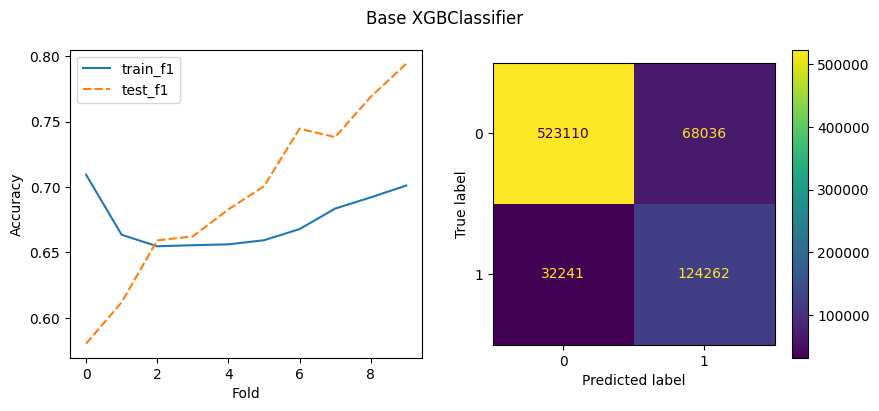

In [18]:
plot_results(scores, cm, "Base XGBClassifier")

In [49]:
ratio = (y_from_2025 == 0).sum() / (y_from_2025 == 1).sum()
scale_weight = round(ratio, 2)
print(f"scale_pos_weight: {scale_weight}")

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        enable_categorical=True,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    ))
])

scores, cm = evaluate_model(pipeline, X_from_2025, y_from_2025, weights_func=combined_weights)

scale_pos_weight: 2.77
------------- Evaluation Results -------------
Train F1       : 0.842 ± 0.078
Test  F1       : 0.706 ± 0.031
Test  Precision: 0.648 ± 0.084
Test  Recall   : 0.792 ± 0.067
Test  ROC_AUC  : 0.903 ± 0.014
Test  PR_AUC   : 0.810 ± 0.031
Test  MCC      : 0.594 ± 0.051

Completed in: 42.32s.


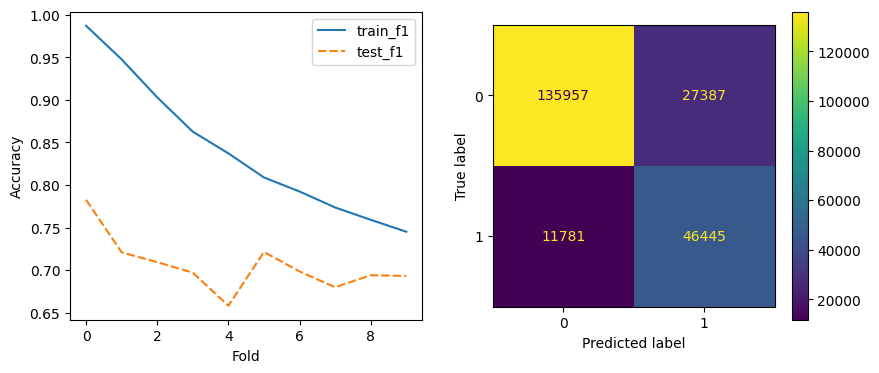

In [50]:
plot_results(scores, cm)

In [51]:
pipeline.fit(X_from_2025, y_from_2025, model__sample_weight=combined_weights(X_from_2025, y_from_2025))
res, metrics, cm = check_on_new_data(pipeline)

In [52]:
display(metrics)

,f1_score,roc_auc,pr_auc,mcc,precision,recall
0,0.755245,0.922233,0.860291,0.630256,0.673422,0.859701


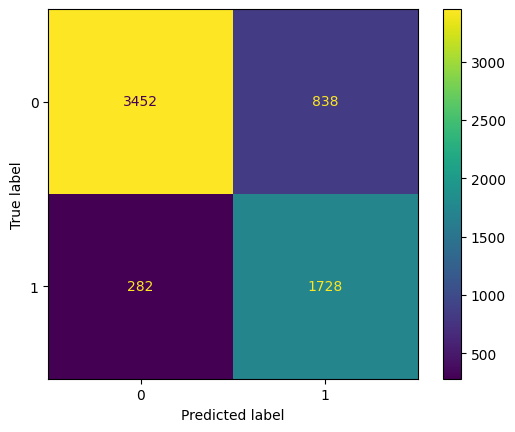

In [53]:
ConfusionMatrixDisplay(cm).plot()

In [54]:
with pd.option_context("display.max_rows", None):
    display(res)

,region_id,time,alarm,prediction,pred_prob_1
0,3,2026-04-09 00:00:00+03:00,0,0,0.044127
1,3,2026-04-09 01:00:00+03:00,0,0,0.036701
2,3,2026-04-09 02:00:00+03:00,0,0,0.117906
3,3,2026-04-09 03:00:00+03:00,0,0,0.127065
4,3,2026-04-09 04:00:00+03:00,0,0,0.080784
5,3,2026-04-09 05:00:00+03:00,0,0,0.101198
6,3,2026-04-09 06:00:00+03:00,0,0,0.316299
7,3,2026-04-09 07:00:00+03:00,0,0,0.037001
8,3,2026-04-09 08:00:00+03:00,0,0,0.023291
9,3,2026-04-09 09:00:00+03:00,0,0,0.004523


# Hyperparameter Tuning — GridSearchCV

## Scoring metrics chosen

* **`f1`**: Balances Precision and Recall for our imbalanced 20/80 split.
* **`average_precision`**: Best for imbalanced binary classification. Summarizes Precision-Recall trade-off without being skewed by the large TN count.

## Parameters searched

* `n_estimators` (100, 300): Number of boosting rounds.
* `max_depth` (4, 6, 8): Maximum depth. Keeps individual learners relatively weak to prevent overfitting.
* `learning_rate` (0.05, 0.1): Step size shrinkage.
* `subsample` (0.8): Uses 80% of rows per tree, introducing randomness.

Need to define custom `RegionAwareTimeSeriesSplit` that will correctly handle our data. It will chose train and test hours and apply them across all regions.

In [31]:
class RegionAwareTimeSeriesSplit(BaseCrossValidator):
    """
    TimeSeriesSplit that splits on unique timestamps,
    ensuring all regions have identical train/test hour boundaries.
    """
    def __init__(self, times, n_splits=10, gap=24, max_train_hours=450*24):
        self.times = np.array(times)               # the 'time' column from X
        self.n_splits = n_splits
        self.gap = gap
        self.max_train_hours = max_train_hours

    def split(self, X, y=None, groups=None):
        unique_times = np.unique(self.times)
        n = len(unique_times)

        # Mirror TimeSeriesSplit logic but on timestamp
        test_size = n // (self.n_splits + 1)

        for i in range(self.n_splits):
            test_end   = n - (self.n_splits - 1 - i) * test_size
            test_start = test_end - test_size
            train_end  = test_start - self.gap

            if train_end <= 0:
                continue

            train_start = max(0, train_end - self.max_train_hours)

            # Get the actual timestamp boundaries
            train_times = unique_times[train_start:train_end]
            test_times  = unique_times[test_start:test_end]

            # Map back to row indices
            train_idx = np.where(np.isin(self.times, train_times))[0]
            test_idx  = np.where(np.isin(self.times, test_times))[0]

            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [58]:
custom_cv = RegionAwareTimeSeriesSplit(
    times=X_from_2025["time"].values,
    n_splits=10,
    gap=24,
    max_train_hours=450 * 24,
)
ratio = (y_from_2025 == 0).sum() / (y_from_2025 == 1).sum()
scale_weight = round(ratio, 2) 
weights = combined_weights(X_from_2025, y_from_2025)

param_grid = {
    "model__n_estimators":  [100, 300],
    "model__max_depth":     [4, 6, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample":     [0.8],
    "model__scale_pos_weight": [scale_weight],
}

X_gs = X.drop(columns=["time", "region_id"], errors='ignore')

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(objective='binary:logistic', random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring={"f1": "f1", "average_precision": "average_precision"},
    refit="f1",
    cv=custom_cv,
    n_jobs=2,
    verbose=2,
    return_train_score=True,
)

t0 = time()

grid_search.fit(X_from_2025, y_from_2025, model__sample_weight=weights)
print(f"\nGridSearchCV completed in: {time() - t0:.2f}s")

print("Best parameters:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest CV F1       : {grid_search.best_score_:.4f}")
print(f"Best CV AUPRC    : {grid_search.cv_results_['mean_test_average_precision'][grid_search.best_index_]:.4f}")

Fitting 10 folds for each of 12 candidates, totalling 120 fits

GridSearchCV completed in: 280.55s
Best parameters:
  model__learning_rate: 0.1
  model__max_depth: 8
  model__n_estimators: 300
  model__scale_pos_weight: 2.77
  model__subsample: 0.8

Best CV F1       : 0.7131
Best CV AUPRC    : 0.8183


In [60]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top5 = (
    cv_results
    .sort_values("mean_test_f1", ascending=False)
    .head(5)
    [[
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__learning_rate",
        "mean_test_f1",
        "mean_test_average_precision",
    ]]
    .rename(columns=lambda c: c.replace("param_classifier__", "").replace("mean_test_", ""))
    .reset_index(drop=True)
)

top5

,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,f1,average_precision
0,300,8,0.10,0.713097,0.818310
1,300,8,0.05,0.682100,0.796491
2,300,6,0.10,0.657704,0.766633
3,100,8,0.10,0.655254,0.768878
4,300,6,0.05,0.626362,0.739545


In [65]:
# tuned_xgb_model = grid_search.best_estimator_
best_params = {
    "model__learning_rate": 0.1,
    "model__max_depth": 8,
    "model__n_estimators": 300,
    "model__scale_pos_weight": 2.77,
    "model__subsample": 0.8,
}

best_pipeline = pipeline_factory(best_params)
scores, cm = evaluate_model(best_pipeline, X_from_2025, y_from_2025, weights_func=combined_weights)

------------- Evaluation Results -------------
Train F1       : 0.785 ± 0.072
Test  F1       : 0.671 ± 0.031
Test  Precision: 0.604 ± 0.057
Test  Recall   : 0.762 ± 0.039
Test  ROC_AUC  : 0.881 ± 0.019
Test  PR_AUC   : 0.772 ± 0.037
Test  MCC      : 0.542 ± 0.050

Completed in: 10.66s.


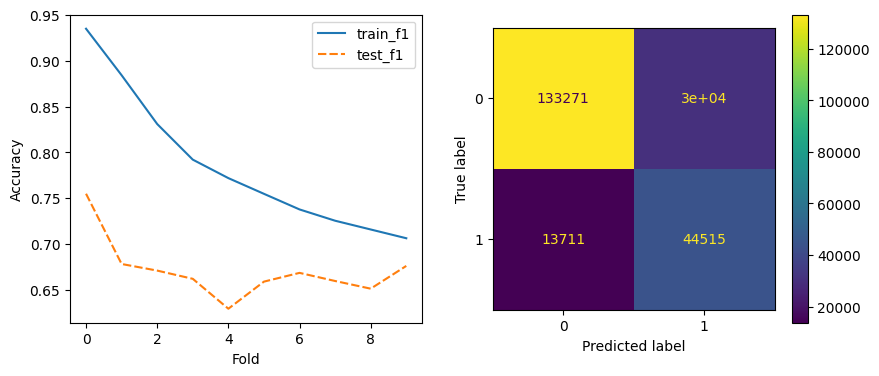

In [66]:
plot_results(scores, cm)

In [68]:
weights = combined_weights(X_from_2025, y_from_2025)
best_pipeline.fit(X_from_2025, y_from_2025, model__sample_weight=weights)
res, metrics, cm = check_on_new_data(best_pipeline)

In [70]:
display(metrics)

,f1_score,roc_auc,pr_auc,mcc,precision,recall
0,0.670814,0.866854,0.759641,0.49639,0.540073,0.885075


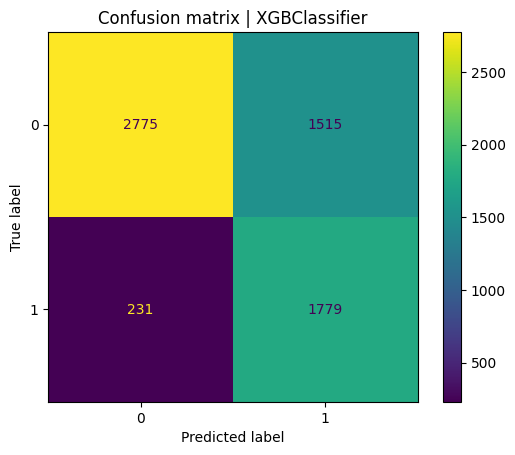

In [85]:
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion matrix | XGBClassifier")
plt.show()

In [76]:
with pd.option_context("display.max_rows", None):
    display(res.loc[res.region_id == 31])

,region_id,time,alarm,prediction,pred_prob_1
6048,31,2026-04-09 00:00:00+03:00,0,1,0.622546
6049,31,2026-04-09 01:00:00+03:00,0,0,0.472919
6050,31,2026-04-09 02:00:00+03:00,0,1,0.818554
6051,31,2026-04-09 03:00:00+03:00,0,1,0.740016
6052,31,2026-04-09 04:00:00+03:00,0,0,0.295070
6053,31,2026-04-09 05:00:00+03:00,1,1,0.526987
6054,31,2026-04-09 06:00:00+03:00,1,1,0.752577
6055,31,2026-04-09 07:00:00+03:00,0,0,0.247136
6056,31,2026-04-09 08:00:00+03:00,0,1,0.748197
6057,31,2026-04-09 09:00:00+03:00,0,0,0.260235


# Top 20 features and weights

XGBoost provides **feature importance** based on "gain" (the average improvement in accuracy brought by a feature to the branches it is on). This tells us which features contribute the most to the model's predictive power.

In [79]:
feature_importances = get_feature_importance(best_pipeline)
feature_importances.head(20)

,feature,importance_pct,importance_std_pct
0,region_id,20.72,1.40
109,neighbor_alarm_count,18.47,0.75
96,alarm_status_12h_ago,2.93,0.31
107,alarm_status_23h_ago,2.89,0.34
89,alarm_status_5h_ago,2.85,0.38
88,alarm_status_4h_ago,2.82,0.25
87,alarm_status_3h_ago,2.53,0.25
90,alarm_status_6h_ago,2.38,0.26
61,alarms_count_1h_ago,1.77,0.56
102,alarm_status_18h_ago,1.69,0.40


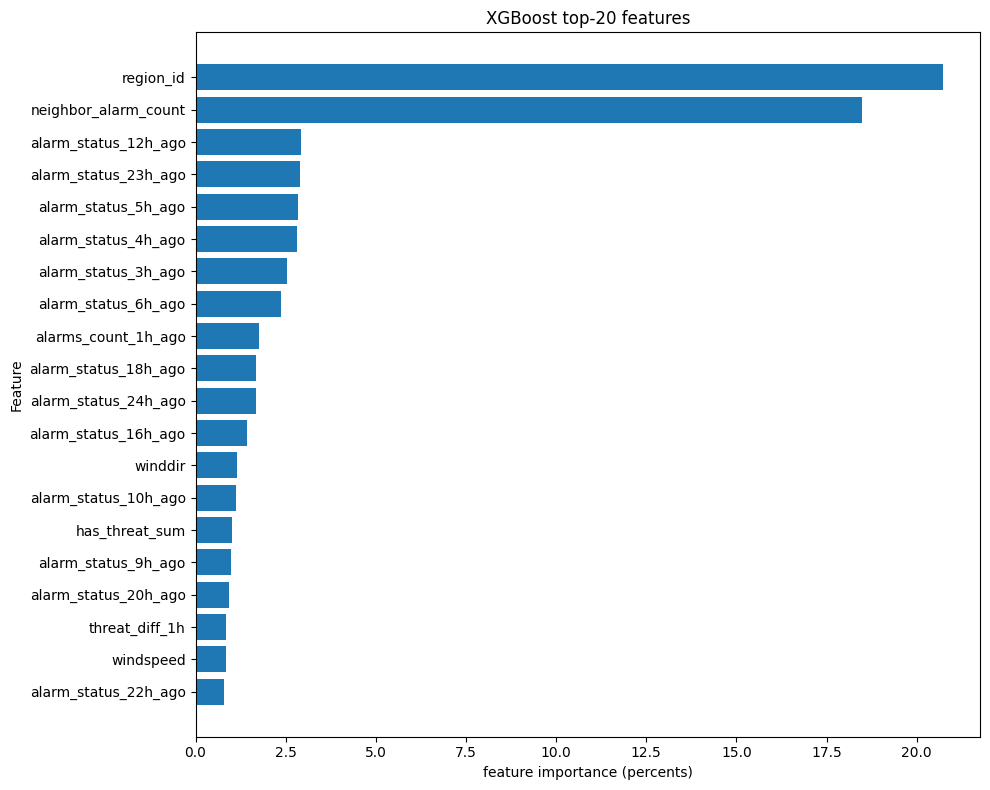

In [81]:
plot_feature_importances(feature_importances.head(20), "XGBoost top-20 features")

# Save model

In [83]:
model_path = Path("app/models/1_xgboost_v2.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as f:
    pickle.dump(best_pipeline, f)